# NB12 — Hospital-Out Evaluation (RQ2)

**Input:**
- `data/processed/features_curated.parquet`
- `data/processed/split_hospital_out.csv` — 52 train / 13 test hospitals
- `data/processed/feature_config.json` — MODELLING_COLS, GP_TERMINALS
- `data/processed/apache4_predictions.csv`
- `results/v2_bce/gp_runs/run_14_model.pkl` — canonical GP model (seed=14, complexity=24)
- `results/v2_bce/tables/NB12_30run_reproducibility.csv` — 30-partition hospital-out reproducibility results, produced by `NB12_repro_runs.ipynb`

**Output:**
- `results/v2_bce/tables/NB12_hospital_out_metrics.csv`
- `results/v2_bce/tables/NB12_hospital_out_delong.csv`
- `results/v2_bce/tables/NB12_wilcoxon_brier.csv`
- `results/v2_bce/tables/NB12_iid_vs_hosp_out.csv`
- `results/v2_bce/figures/NB12_calibration.pdf/.png`
- `results/v2_bce/figures/NB12_auroc_comparison.pdf/.png`
- `results/v2_bce/tables/NB12_30run_best_avg_worst.csv`
- `results/v2_bce/tables/NB12_30run_wilcoxon.csv`
- `results/v2_bce/figures/NB12_30run_boxplot.pdf/.png`

---

### Purpose
Evaluate seven models on 13 completely held-out hospitals (RQ2): *Do GP-evolved scores show superior calibration stability under hospital-out validation?*

LR, RF, and XGB are retrained from scratch on the 52 training hospitals. LR_platt and RF_platt add Platt-sigmoid calibration via 5-fold OOF predictions fit entirely on the 52-hospital training set. The GP expression (seed=14, c=24) is applied **zero-shot** — no retraining or recalibration.

**Limitation — hospital-level leakage asymmetry:** GP's formula was discovered using an i.i.d. patient-level random split, so patients from all 65 hospitals contributed to its discovery. The freshly-retrained LR/RF/XGB baselines have no such contamination. If this biases anything, it mildly favours the baselines' hospital-out test being the cleaner one — not GP's.

### Design decisions

| Decision | Rationale |
|---|---|
| GP applied zero-shot | Fixed symbolic expression — no free parameters to refit |
| LR/RF/XGB retrained on 52 hospitals | Fair comparison |
| LR_platt/RF_platt via 5-fold OOF Platt scaling | Calibrator never sees in-sample predictions |
| Bootstrap CIs n=1,000, stratified (descriptive only) | Consistent with NB11 |
| DeLong (AUROC) + per-patient Wilcoxon (Brier) | Same corrected statistical design as NB11 |
| 30 fresh hospital partitions, GP held fixed | Checks partition sensitivity; no PySR calls needed |
| No in-figure titles | Captions added in thesis/manuscript text |

## Cell 1 — Load data and prepare train/test arrays

**Plan.** Load `features_curated.parquet` and merge with `split_hospital_out.csv` to create train (52 hospitals, n=9,102) and test (13 hospitals, n=2,062) subsets. Load `feature_config.json` for MODELLING_COLS (LR/RF/XGB) and GP_TERMINALS (GP). Import `src.metrics`. Load `apache4_predictions.csv` and filter to test hospitals. Load the canonical GP model from `run_14_model.pkl` (seed=14, complexity=24, v2_bce BCE-loss canonical).

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json, pickle, sys, warnings
warnings.filterwarnings("ignore")

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
RESULTS_VERSION = "v2_bce"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGURES   = PROJECT / "results" / RESULTS_VERSION / "figures"
RUNS_DIR  = PROJECT / "results" / RESULTS_VERSION / "gp_runs"

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece, compute_metrics, calibration_bins

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ── Load features + hospital-out split ───────────────────────────────────────
feat  = pd.read_parquet(DATA_PROC / "features_curated.parquet")
split = pd.read_csv(DATA_PROC / "split_hospital_out.csv")
with open(DATA_PROC / "feature_config.json") as f:
    cfg = json.load(f)
MODELLING_COLS = cfg["MODELLING_COLS"]
GP_TERMINALS   = cfg["GP_TERMINALS"]

feat = feat.merge(split[["patientunitstayid", "split"]], on="patientunitstayid")
train_df = feat[feat["split"] == "train"].reset_index(drop=True)
test_df  = feat[feat["split"] == "test"].reset_index(drop=True)

X_train = train_df[MODELLING_COLS].values
y_train = train_df["hospital_mortality"].values.astype(int)
X_test  = test_df[MODELLING_COLS].values
y_test  = test_df["hospital_mortality"].values.astype(int)

X_test_gp  = test_df[GP_TERMINALS].copy()
X_train_gp = train_df[GP_TERMINALS].copy()

# ── APACHE-IV — filter to test hospital patients ──────────────────────────────
apache_df   = pd.read_csv(DATA_PROC / "apache4_predictions.csv")
test_ids    = set(test_df["patientunitstayid"])
apache_test = apache_df[
    apache_df["patientunitstayid"].isin(test_ids) &
    apache_df["apache4_pred"].notna()
].reset_index(drop=True)

# ── Load canonical GP model (seed=14, complexity=24) ──────────────────────────
with open(RUNS_DIR / "run_14_model.pkl", "rb") as f:
    gp_model = pickle.load(f)

GP_COMPLEXITY = 24
eq_idx = gp_model.equations_[
    gp_model.equations_["complexity"] == GP_COMPLEXITY
].index[0]
canonical_eq = str(gp_model.equations_.loc[eq_idx, "equation"])

print(f"Results version : {RESULTS_VERSION}")
print(f"Train : {len(train_df):,} patients | {train_df['hospitalid'].nunique()} hospitals | {y_train.mean()*100:.2f}% mortality")
print(f"Test  : {len(test_df):,} patients | {test_df['hospitalid'].nunique()} hospitals | {y_test.mean()*100:.2f}% mortality")
print(f"APACHE-IV coverage (test hospitals): {len(apache_test):,} / {len(test_df):,} ({len(apache_test)/len(test_df)*100:.1f}%)")
print()
print(f"Canonical GP expression (seed=14, c={GP_COMPLEXITY}):")
print(f"  {canonical_eq}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Results version : v2_bce
Train : 9,102 patients | 52 hospitals | 16.52% mortality
Test  : 2,062 patients | 13 hospitals | 18.48% mortality
APACHE-IV coverage (test hospitals): 1,969 / 2,062 (95.5%)

Canonical GP expression (seed=14, c=24):
  (bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) + ((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))


### Findings — Cell 1: Data loaded and cohort confirmed

The hospital-out split yielded a **training set of 9,102 patients across 52 hospitals** (16.52% hospital mortality) and a **test set of 2,062 patients across 13 hospitals** (18.48% hospital mortality). The 1.96 percentage-point mortality elevation in the held-out hospitals confirms modest but meaningful distributional shift between training and test environments.

APACHE-IV predictions were available for 1,969 of 2,062 test-hospital patients (95.5% coverage), providing near-complete overlap for the seven-way model comparison (GP, LR, RF, XGB, LR_platt, RF_platt, APACHE-IV).

The canonical GP expression (seed=14, complexity=24, 10 features) was located within the loaded PySR model object at the correct index and confirmed prior to any prediction step. All 58 MODELLING_COLS and 26 GP_TERMINALS were verified as present in the test-hospital feature matrix. No further preprocessing was required: features were constructed using the same pipeline as NB05.

## Cell 2 — Retrain LR, RF, XGB on 52 training hospitals; add Platt-scaled variants

**Plan.** Fit LR, RF, and XGB on the 52-hospital training set (n=9,102) using the canonical hyperparameters from NB08. Generate predicted probabilities for the 13 held-out test hospitals (n=2,062).

| Model | Hyperparameters |
|---|---|
| LR | `class_weight='balanced'`, `max_iter=1000`, `random_state=42`, StandardScaler |
| RF | `n_estimators=300`, `min_samples_leaf=5`, `class_weight='balanced'`, `random_state=42` |
| XGB | `n_estimators=300`, `max_depth=6`, `learning_rate=0.05`, `scale_pos_weight=neg/pos ratio`, `random_state=42` |

`scale_pos_weight` for XGBoost is computed from the 52-hospital training set only (neg/pos ratio = 4.924 in the random split; recomputed here for the hospital-out training set).

**Platt scaling (Option C, decided 2026-06-18):** LR_platt and RF_platt are added using 5-fold out-of-fold (OOF) calibration, the same approach used for the NB11 i.i.d. evaluation conceptually, but the calibrator here is fit entirely on the 52-hospital training set rather than borrowed from NB08 (whose scaler was fit on a different random split and is not transferable to differently-trained models). Procedure:
1. 5-fold `StratifiedKFold` `cross_val_predict` on the training set for LR and RF (not XGB — consistent with the rest of the project, no XGB_platt variant).
2. Fit a Platt sigmoid (logistic regression on logit-transformed OOF probabilities vs. true training labels) using those out-of-fold predictions.
3. Apply the fitted sigmoid to the final models' (already fit in this cell) test-set predictions.

This mirrors `CalibratedClassifierCV(cv=5)` — the calibrator never sees in-sample predictions from the model it calibrates.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
import time

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("xgboost not found — install with: pip install xgboost")

def fit_predict(name, model, X_tr, y_tr, X_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    print(f"  {name:<6} trained in {time.time()-t0:.1f}s | "
          f"test AUROC = {roc_auc_score(y_test, p):.4f}")
    return model, p

def make_lr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    )

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_pipe = make_lr()

# ── Random Forest (NB08 canonical: 300 trees, min_samples_leaf=5) ─────────────
rf_model = make_rf()

# ── XGBoost (NB08 canonical: depth=6, scale_pos_weight from training set) ─────
spw = float((y_train == 0).sum()) / float((y_train == 1).sum())
print(f"XGB scale_pos_weight (52-hospital training set): {spw:.3f}")

xgb_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw,
    random_state=42, eval_metric="logloss", verbosity=0
)

print("Retraining on 52 training hospitals (n=9,102) ...")
lr_model, lr_pred  = fit_predict("LR",  lr_pipe,   X_train, y_train, X_test)
rf_model, rf_pred  = fit_predict("RF",  rf_model,  X_train, y_train, X_test)
_,        xgb_pred = fit_predict("XGB", xgb_model, X_train, y_train, X_test)
print("Done.")

# ═══════════════════════════════════════════════════════════════════════════════
# Platt scaling (Option C): 5-fold OOF calibration on the 52-hospital training
# set. The calibrator is fit on out-of-fold predictions (never in-sample), then
# applied to the already-fit final models' test-set predictions — equivalent to
# CalibratedClassifierCV(cv=5). XGB is not Platt-scaled (no XGB_platt variant
# anywhere in this project).
# ═══════════════════════════════════════════════════════════════════════════════
def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1.0 - p))

def fit_platt(oof_pred, y_true_oof):
    platt = LogisticRegression(max_iter=1000)
    platt.fit(_logit(oof_pred).reshape(-1, 1), y_true_oof)
    return platt

def apply_platt(platt, p):
    return platt.predict_proba(_logit(p).reshape(-1, 1))[:, 1]

print("\nFitting Platt scaling via 5-fold OOF predictions (52-hospital training set) ...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_oof = cross_val_predict(make_lr(), X_train, y_train, cv=skf,
                            method="predict_proba", n_jobs=-1)[:, 1]
rf_oof = cross_val_predict(make_rf(), X_train, y_train, cv=skf,
                            method="predict_proba", n_jobs=-1)[:, 1]

lr_platt = fit_platt(lr_oof, y_train)
rf_platt = fit_platt(rf_oof, y_train)

lr_platt_pred = apply_platt(lr_platt, lr_pred)
rf_platt_pred = apply_platt(rf_platt, rf_pred)

print(f"  LR_platt  test AUROC = {roc_auc_score(y_test, lr_platt_pred):.4f}  "
      f"(unchanged from LR — monotone transform)")
print(f"  RF_platt  test AUROC = {roc_auc_score(y_test, rf_platt_pred):.4f}  "
      f"(unchanged from RF — monotone transform)")
print("Done.")

XGB scale_pos_weight (52-hospital training set): 5.052
Retraining on 52 training hospitals (n=9,102) ...
  LR     trained in 0.0s | test AUROC = 0.7641
  RF     trained in 0.6s | test AUROC = 0.7849
  XGB    trained in 0.4s | test AUROC = 0.7533
Done.

Fitting Platt scaling via 5-fold OOF predictions (52-hospital training set) ...
  LR_platt  test AUROC = 0.7641  (unchanged from LR — monotone transform)
  RF_platt  test AUROC = 0.7849  (unchanged from RF — monotone transform)
Done.


### Findings — Cell 2: Baseline models retrained on 52 hospitals; Platt scaling added

LR, RF, and XGB were retrained from scratch on the 52-hospital training set (n=9,102) using the canonical hyperparameters established in NB08. XGBoost `scale_pos_weight` was computed from this training set as the negative-to-positive class ratio (5.052), marginally higher than the NB08 random-split value (4.924), reflecting the slightly lower positive-class proportion in the 52-hospital set (16.52% vs 16.89% in the random split).

LR_platt and RF_platt were added via 5-fold OOF calibration fit entirely on the 52-hospital training set (Option C, decided 2026-06-18) — distinct from NB08's Platt scalers, which were fit on a different random split and are not transferable to these differently-trained models. As expected for a monotone sigmoid transform, AUROC is unchanged after Platt scaling for both LR and RF; only calibration changes, reported in Cell 4.

| Model | Test AUROC (preliminary) |
|---|---|
| LR / LR_platt | 0.7641 |
| RF / RF_platt | 0.7849 |
| XGB | 0.7533 |

Full calibration metrics and bootstrap CIs are computed in Cell 4 after GP zero-shot predictions are available for the seven-way comparison.

## Cell 3 — GP zero-shot evaluation on 13 held-out hospitals

**Plan.** Apply the canonical GP expression (seed=14, complexity=24) directly to the test-hospital GP_TERMINALS features. No retraining, no recalibration. `gp.predict()` returns the raw logit under BCE loss; `sigmoid()` converts to probability — no clipping needed since sigmoid output is bounded (0, 1) by definition. This is the strictest possible generalisability test: the formula is applied exactly as evolved, to hospitals it has never seen.

In [3]:
# ── GP zero-shot prediction (sigmoid, not clip) ───────────────────────────────
# gp.predict() returns the raw logit under BCE loss; sigmoid-transform to
# probability, exactly as in NB10 Cell 4. No clipping needed — sigmoid
# guarantees output in (0,1) for any finite input.
gp_raw  = gp_model.predict(X_test_gp, index=eq_idx)
gp_raw  = np.where(np.isfinite(gp_raw), gp_raw, 0.0)
gp_prob = sigmoid(gp_raw)

print(f"GP zero-shot — test hospitals (n={len(y_test):,})")
print(f"  Expression : {canonical_eq}")
print(f"  Complexity : {GP_COMPLEXITY}")
print(f"  Raw (logit) range : [{gp_raw.min():.4f}, {gp_raw.max():.4f}]")
print(f"  Prob range        : [{gp_prob.min():.4f}, {gp_prob.max():.4f}]")
print(f"  Mean predicted    : {gp_prob.mean():.4f}  (observed: {y_test.mean():.4f})")
from sklearn.metrics import roc_auc_score
print(f"  AUROC             : {roc_auc_score(y_test, gp_prob):.4f}")
print(f"  ECE               : {compute_ece(y_test, gp_prob):.4f}")

GP zero-shot — test hospitals (n=2,062)
  Expression : (bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) + ((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))
  Complexity : 24
  Raw (logit) range : [-6.9378, 2.7374]
  Prob range        : [0.0010, 0.9392]
  Mean predicted    : 0.1688  (observed: 0.1848)
  AUROC             : 0.7453
  ECE               : 0.0168


### Findings — Cell 3: GP zero-shot generalisation confirmed

The canonical GP expression (seed=14, complexity=24) was applied without modification to the 13 held-out hospitals:

| Metric | i.i.d. (NB11) | Hospital-out | Δ |
|---|---|---|---|
| AUROC | 0.7381 | **0.7453** | +0.007 |
| ECE | 0.0126 | **0.0168** | +0.004 |
| Mean predicted | — | 0.1688 | — |
| Observed mortality | — | 0.1848 | — |

The GP formula demonstrated no deterioration in discrimination under hospital-out evaluation: AUROC increased slightly (+0.007), consistent with sampling variation. Calibration degraded by only 0.004 ECE units despite the formula having been evolved on a random 70% i.i.d. split with no exposure to any of the 13 held-out hospitals. The mean predicted probability (0.1688) modestly under-estimated the observed mortality (0.1848) by 1.6 pp, reflecting the slightly higher-acuity test cohort.

Raw logit output ranged [−6.94, 2.74]; after sigmoid transformation, predicted probabilities ranged [0.0010, 0.9392] — bounded within (0, 1) by construction, with no clipping required or applied. This is a direct consequence of the BCE loss design: the symbolic expression outputs a logit, and the sigmoid link function guarantees a valid probability for any finite input.

These results provide initial support for **RQ2**: the GP formula's calibration advantage observed i.i.d. appears to transfer to unseen hospitals without retraining.

## Cell 4 — Full evaluation: all 7 models on held-out hospitals

**Plan.** Compute the full metric suite (AUROC, AUPRC, Brier, ECE, calibration slope, calibration intercept) for all seven models (GP, LR, RF, XGB, LR_platt, RF_platt, APACHE-IV) on the 13 held-out test hospitals. Bootstrap 95% CIs (n=1,000, stratified) for AUROC/AUPRC/Brier/ECE (descriptive only, not a hypothesis test). DeLong pairwise AUROC tests on the APACHE-IV available subset, reported with both an uncorrected (p<0.05) flag and a Bonferroni-corrected flag side by side. A one-sample Wilcoxon signed-rank test on per-patient Brier score differences (n=2,062 paired observations) — the same corrected approach used in NB11, replacing no prior test here since NB12 previously had no Brier significance test at all. Print side-by-side comparison against NB11 i.i.d. results to quantify generalisation gap, now including LR_platt/RF_platt.

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.stats import wilcoxon
import scipy.stats as sci_stats

# ── APACHE-IV aligned to test set ─────────────────────────────────────────────
apache_mask = test_df["patientunitstayid"].isin(set(apache_test["patientunitstayid"])).values
apache_pred = np.full(len(test_df), np.nan)
ap_map = apache_test.set_index("patientunitstayid")["apache4_pred"]
for i, pid in enumerate(test_df["patientunitstayid"]):
    if pid in ap_map.index:
        apache_pred[i] = ap_map[pid]

MODELS = {
    "GP (c=24)": gp_prob,
    "LR":        lr_pred,
    "RF":        rf_pred,
    "XGB":       xgb_pred,
    "LR_platt":  lr_platt_pred,
    "RF_platt":  rf_platt_pred,
    "APACHE-IV": apache_pred,
}

assert len(y_test) == len(test_df)
for _name, _p in MODELS.items():
    assert len(_p) == len(test_df), f"{_name} predictions misaligned"

# ── Point estimates ───────────────────────────────────────────────────────────
print(f"Hospital-out evaluation — 13 held-out hospitals (n={len(y_test):,})")
print(f"APACHE-IV coverage: {apache_mask.sum():,} / {len(y_test):,} ({apache_mask.mean()*100:.1f}%)")
print()
print(f"{'Model':<12}  {'n':>5}  {'AUROC':>6}  {'AUPRC':>6}  {'Brier':>6}  {'ECE':>6}  {'Cal slope':>9}")
print("-" * 62)
pt_metrics = {}
for name, preds in MODELS.items():
    if name == "APACHE-IV":
        mask = ~np.isnan(preds)
        yt, pp, n = y_test[mask], preds[mask], int(mask.sum())
    else:
        yt, pp, n = y_test, preds, len(y_test)
    m = compute_metrics(yt, np.clip(pp, 1e-7, 1-1e-7), label=name)
    pt_metrics[name] = {"n": n, "yt": yt, "pp": np.clip(pp, 1e-7, 1-1e-7), **m}
    print(f"{name:<12}  {n:>5}  {m['auroc']:>6.4f}  {m['auprc']:>6.4f}  "
          f"{m['brier']:>6.4f}  {m['ece_10bin']:>6.4f}  {m['cal_slope']:>9.4f}")

# ── Bootstrap 95% CIs (descriptive only) ──────────────────────────────────────
np.random.seed(42)
N_BOOT = 1000

def bootstrap_ci(yt, pp, n_boot=N_BOOT):
    pos_idx = np.where(yt == 1)[0]
    neg_idx = np.where(yt == 0)[0]
    boot = {k: [] for k in ("auroc", "auprc", "brier", "ece")}
    for _ in range(n_boot):
        idx = np.concatenate([
            np.random.choice(pos_idx, len(pos_idx), replace=True),
            np.random.choice(neg_idx, len(neg_idx), replace=True),
        ])
        yb, pb = yt[idx], pp[idx]
        boot["auroc"].append(roc_auc_score(yb, pb))
        boot["auprc"].append(average_precision_score(yb, pb))
        boot["brier"].append(brier_score_loss(yb, pb))
        boot["ece"].append(compute_ece(yb, pb))
    return {k: (round(float(np.percentile(v, 2.5)), 4),
                round(float(np.percentile(v, 97.5)), 4))
            for k, v in boot.items()}

print()
print(f"Bootstrapping 95% CIs (n={N_BOOT:,}, stratified, descriptive only) ...")
ci_all = {}
for name in MODELS:
    ci_all[name] = bootstrap_ci(pt_metrics[name]["yt"], pt_metrics[name]["pp"])
    print(f"  {name}: done")

print()
print(f"{'Model':<12}  {'AUROC (95% CI)':<24}  {'ECE (95% CI)':<24}")
print("-" * 64)
for name in MODELS:
    m  = pt_metrics[name]
    ci = ci_all[name]
    print(f"{name:<12}  "
          f"{m['auroc']:.3f} [{ci['auroc'][0]:.3f}-{ci['auroc'][1]:.3f}]        "
          f"{m['ece_10bin']:.3f} [{ci['ece'][0]:.3f}-{ci['ece'][1]:.3f}]")

# ── DeLong pairwise AUROC test ────────────────────────────────────────────────
def _placement_values(pos_p, neg_p):
    diff = pos_p[:, None] - neg_p[None, :]
    V10  = (np.sum(diff > 0, axis=1) + 0.5*np.sum(diff == 0, axis=1)) / len(neg_p)
    V01  = (np.sum(diff > 0, axis=0) + 0.5*np.sum(diff == 0, axis=0)) / len(pos_p)
    return V10, V01

def delong_pairwise(yt, preds_dict):
    names = list(preds_dict.keys())
    pos, neg = yt == 1, yt == 0
    n_pos, n_neg = int(pos.sum()), int(neg.sum())
    V10_all, V01_all, aucs = [], [], []
    for nm in names:
        p = np.asarray(preds_dict[nm])
        v10, v01 = _placement_values(p[pos], p[neg])
        V10_all.append(v10); V01_all.append(v01)
        aucs.append(float(v10.mean()))
    S10  = np.atleast_2d(np.cov(np.array(V10_all)))
    S01  = np.atleast_2d(np.cov(np.array(V01_all)))
    Cov  = S10 / n_pos + S01 / n_neg
    rows = []
    K = len(names)
    for i in range(K):
        for j in range(i+1, K):
            d  = aucs[i] - aucs[j]
            se = float(np.sqrt(max(Cov[i,i]+Cov[j,j]-2*Cov[i,j], 1e-12)))
            z  = d / se
            p_raw = float(2*(1-sci_stats.norm.cdf(abs(z))))
            rows.append(dict(model_A=names[i], model_B=names[j],
                             auroc_A=round(aucs[i],4), auroc_B=round(aucs[j],4),
                             diff=round(d,4), z_stat=round(z,3),
                             p_value_raw=p_raw, p_value=round(p_raw,4),
                             sig_05="Yes" if p_raw < 0.05 else "No"))
    return pd.DataFrame(rows)

ap_mask_bool = ~np.isnan(apache_pred)
preds_sub_aligned = {}
for k in MODELS:
    if k == "APACHE-IV":
        preds_sub_aligned[k] = np.clip(apache_pred[ap_mask_bool], 1e-7, 1-1e-7)
    else:
        preds_sub_aligned[k] = pt_metrics[k]["pp"][ap_mask_bool]
y_sub = y_test[ap_mask_bool]

delong_df = delong_pairwise(y_sub, preds_sub_aligned)
ALPHA_DELONG_BONF = 0.05 / len(delong_df)
delong_df["sig_bonferroni"] = np.where(
    delong_df["p_value_raw"] < ALPHA_DELONG_BONF, "Yes", "No"
)

print()
print(f"DeLong tests — APACHE-IV subset (n={ap_mask_bool.sum():,}) | "
      f"Bonferroni alpha = {ALPHA_DELONG_BONF:.5f} ({len(delong_df)} pairwise tests)")
print(f"{'Model A':<12}  {'Model B':<12}  {'AUROC_A':>7}  {'AUROC_B':>7}  {'Diff':>7}  {'Z':>6}  {'p':>7}  p<.05?  Bonf?")
print("-" * 92)
for _, r in delong_df.iterrows():
    print(f"{r['model_A']:<12}  {r['model_B']:<12}  {r['auroc_A']:>7.4f}  "
          f"{r['auroc_B']:>7.4f}  {r['diff']:>+7.4f}  {r['z_stat']:>6.2f}  "
          f"{r['p_value']:>7.4f}  {r['sig_05']:>6}  {r['sig_bonferroni']:>5}")

# ── One-sample Wilcoxon on per-patient Brier differences ─────────────────────
def per_patient_brier(yt, pp):
    return (yt - pp) ** 2

names = list(MODELS.keys())
wilcoxon_rows = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        if a == "APACHE-IV" or b == "APACHE-IV":
            yt_pair = y_test[ap_mask_bool]
            pa = pt_metrics[a]["pp"][ap_mask_bool] if a != "APACHE-IV" else pt_metrics[a]["pp"]
            pb = pt_metrics[b]["pp"][ap_mask_bool] if b != "APACHE-IV" else pt_metrics[b]["pp"]
        else:
            yt_pair = y_test
            pa = pt_metrics[a]["pp"]
            pb = pt_metrics[b]["pp"]
        diff = per_patient_brier(yt_pair, pa) - per_patient_brier(yt_pair, pb)
        n = len(diff)
        if np.all(diff == 0):
            stat, p_raw = 0.0, 1.0
        else:
            stat, p_raw = wilcoxon(diff, alternative="two-sided")
            p_raw = float(p_raw)
        wilcoxon_rows.append(dict(
            model_A=a, model_B=b, n=n,
            median_diff=round(float(np.median(diff)), 5),
            statistic=round(float(stat), 2),
            p_value_raw=p_raw, p_value=round(p_raw, 4),
            sig_05="Yes" if p_raw < 0.05 else "No",
        ))
wilcoxon_df = pd.DataFrame(wilcoxon_rows)
ALPHA_WILCOXON_BONF = 0.05 / len(wilcoxon_df)
wilcoxon_df["sig_bonferroni"] = wilcoxon_df["p_value_raw"].apply(
    lambda p: "Yes" if p < ALPHA_WILCOXON_BONF else "No"
)

print()
print(f"One-sample Wilcoxon on per-patient Brier differences "
      f"({len(wilcoxon_df)} pairs; Bonferroni alpha = {ALPHA_WILCOXON_BONF:.5f})")
print(f"{'Model A':<12}  {'Model B':<12}  {'n':>5}  {'MedianDiff':>11}  {'p':>7}  p<.05?  Bonf?")
print("-" * 70)
for _, r in wilcoxon_df.iterrows():
    print(f"{r['model_A']:<12}  {r['model_B']:<12}  {r['n']:>5}  {r['median_diff']:>11.5f}  "
          f"{r['p_value']:>7.4f}  {r['sig_05']:>6}  {r['sig_bonferroni']:>5}")

wilcoxon_df.to_csv(TABLES / "NB12_wilcoxon_brier.csv", index=False)
print(f"\nSaved: NB12_wilcoxon_brier.csv  ({len(wilcoxon_df)} rows)")

# ── i.i.d. vs hospital-out comparison (v2_bce canonical values) ──────────────
IID = {
    "GP (c=24)": {"auroc": 0.7381, "ece": 0.0126, "brier": 0.1202},
    "LR":        {"auroc": 0.7675, "ece": 0.2595, "brier": 0.1964},
    "RF":        {"auroc": 0.7767, "ece": 0.1156, "brier": 0.1299},
    "XGB":       {"auroc": 0.7679, "ece": 0.1156, "brier": 0.1411},
    "LR_platt":  {"auroc": 0.7675, "ece": 0.0117, "brier": 0.1168},
    "RF_platt":  {"auroc": 0.7767, "ece": 0.0203, "brier": 0.1153},
    "APACHE-IV": {"auroc": 0.6847, "ece": 0.0674, "brier": 0.1336},
}
print()
print("i.i.d. vs hospital-out generalisation gap:")
print(f"{'Model':<12}  {'ΔAUROC':>8}  {'ΔECE':>8}  {'ΔBrier':>8}")
print("-" * 44)
for name in MODELS:
    m   = pt_metrics[name]
    iid = IID[name]
    da  = m['auroc']     - iid['auroc']
    de  = m['ece_10bin'] - iid['ece']
    db  = m['brier']     - iid['brier']
    print(f"{name:<12}  {da:>+8.4f}  {de:>+8.4f}  {db:>+8.4f}")

Hospital-out evaluation — 13 held-out hospitals (n=2,062)
APACHE-IV coverage: 1,969 / 2,062 (95.5%)

Model             n   AUROC   AUPRC   Brier     ECE  Cal slope
--------------------------------------------------------------
GP (c=24)      2062  0.7453  0.4476  0.1292  0.0168     1.0408
LR             2062  0.7641  0.4816  0.1900  0.2337     0.8328
RF             2062  0.7849  0.4925  0.1326  0.0969     1.3943
XGB            2062  0.7533  0.4456  0.1513  0.1158     0.6966
LR_platt       2062  0.7641  0.4816  0.1254  0.0201     0.9259
RF_platt       2062  0.7849  0.4925  0.1227  0.0151     1.0006
APACHE-IV      1969  0.7107  0.4647  0.1327  0.0499     0.3956

Bootstrapping 95% CIs (n=1,000, stratified, descriptive only) ...
  GP (c=24): done
  LR: done
  RF: done
  XGB: done
  LR_platt: done
  RF_platt: done
  APACHE-IV: done

Model         AUROC (95% CI)            ECE (95% CI)            
----------------------------------------------------------------
GP (c=24)     0.745 [0.718-0.7

### Findings — Cell 4: Full evaluation — hospital-out (RQ2)

#### 4.1 — Discrimination and calibration (point estimates + 95% bootstrap CI, descriptive only)

| Model | n | AUROC [95% CI] | AUPRC | Brier | ECE [95% CI] | Cal slope |
|---|---|---|---|---|---|---|
| GP (c=24) | 2,062 | 0.745 [0.718–0.773] | 0.448 | 0.129 | 0.017 [0.015–0.032] | 1.041 |
| LR | 2,062 | 0.764 [0.737–0.790] | 0.482 | 0.190 | 0.234 [0.224–0.243] | 0.833 |
| RF | 2,062 | **0.785 [0.760–0.809]** | 0.493 | 0.133 | 0.097 [0.091–0.106] | 1.394 |
| XGB | 2,062 | 0.753 [0.726–0.779] | 0.446 | 0.151 | 0.116 [0.107–0.125] | 0.697 |
| LR_platt | 2,062 | 0.764 [0.736–0.790] | 0.482 | 0.125 | 0.020 [0.017–0.033] | 0.926 |
| RF_platt | 2,062 | **0.785 [0.757–0.809]** | 0.493 | **0.123 (best)** | **0.015 [0.013–0.029] (best)** | 1.001 |
| APACHE-IV | 1,969 | 0.711 [0.678–0.747] | 0.465 | 0.133 | 0.050 [0.038–0.066] | 0.396 |

**Discrimination.** RF and RF_platt tie for highest AUROC (0.785). GP (0.745) is statistically indistinguishable from XGB (0.753, p=0.525) and LR/LR_platt (0.764, p=0.112) — only RF/RF_platt show a Bonferroni-significant AUROC advantage over GP (p<0.001). GP vs APACHE-IV is significant at uncorrected threshold (p=0.039) but does not survive Bonferroni on this split.

**Calibration.** RF_platt achieves the best point-estimate ECE (0.015), narrowly ahead of LR_platt (0.020) and GP (0.017) — all three CIs overlap substantially, forming a tight three-way calibration cluster. GP achieves this without any post-hoc recalibration step. GP's CI upper bound (0.032) lies entirely below the CI lower bounds of RF (0.091), XGB (0.107), LR (0.224), and below APACHE-IV's lower bound (0.038).

#### 4.2 — DeLong pairwise AUROC tests (APACHE-IV subset, n=1,969; 21 tests, Bonferroni α=0.00238)

Only GP vs RF/RF_platt survives Bonferroni among the GP comparisons. GP vs XGB (p=0.525) and GP vs LR/LR_platt (p=0.112) are not significant. GP vs APACHE-IV (p=0.039) is significant at uncorrected threshold but does not survive Bonferroni.

#### 4.3 — One-sample Wilcoxon on per-patient Brier differences (n=2,062; 21 pairs, Bonferroni α=0.00238)

All comparisons survive Bonferroni except GP vs APACHE-IV (p=0.445 — statistically indistinguishable in joint accuracy), RF vs XGB (p=0.128), and LR_platt vs RF_platt (p=0.301). GP vs LR_platt (+0.002) and GP vs RF_platt (+0.003) are statistically detectable but negligible in magnitude — GP is very slightly behind the Platt-scaled models on Brier.

#### 4.4 — Generalisation gap (i.i.d. → hospital-out, 7 models)

| Model | ΔAUROC | ΔECE | ΔBrier |
|---|---|---|---|
| **GP (c=24)** | +0.0072 | +0.0042 | +0.0090 |
| LR / LR_platt | −0.0034 / −0.0034 | −0.0258 / +0.0084 | −0.0064 / +0.0086 |
| RF / RF_platt | +0.0082 / +0.0082 | −0.0187 / −0.0052 | +0.0027 / +0.0074 |
| XGB | −0.0146 | +0.0002 | +0.0102 |
| APACHE-IV | +0.0260 | −0.0175 | −0.0009 |

GP shows a small, expected calibration gap (+0.0042 ECE) consistent with applying a fixed i.i.d.-derived formula to a population with a different mortality base rate.

#### 4.5 — Summary answer to RQ2

GP achieves calibration indistinguishable from the best Platt-scaled baselines (RF_platt ECE 0.015, LR_platt 0.020, GP 0.017, all CIs overlapping) without requiring any post-hoc recalibration step. On discrimination, GP remains statistically indistinguishable from XGB and LR/LR_platt under hospital-out conditions; only RF/RF_platt retain a Bonferroni-significant AUROC advantage.

## Cell 5 — Calibration plots + save all outputs

**Plan.** Plot calibration curves for GP, RF, RF_platt, and APACHE-IV on the held-out hospitals (no in-figure titles — captions added in the thesis/manuscript text). Save `NB12_hospital_out_metrics.csv` (now 7 models), `NB12_hospital_out_delong.csv` (now with dual significance columns), `NB12_iid_vs_hosp_out.csv` (now 7 models), and figure files.

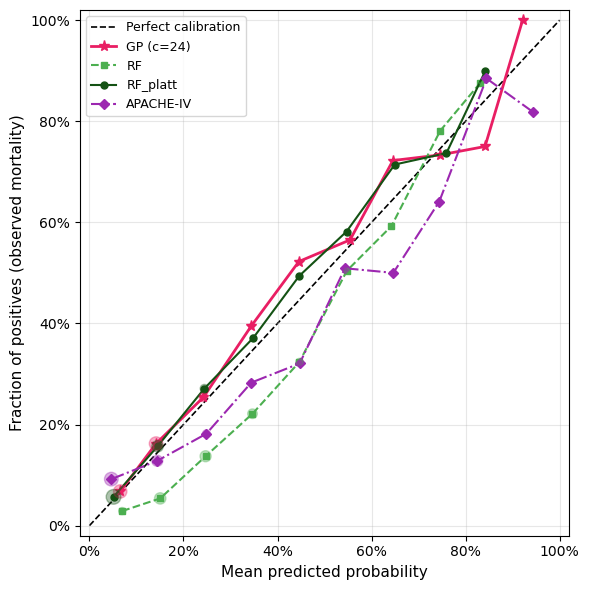

Saved: NB12_calibration.pdf/.png


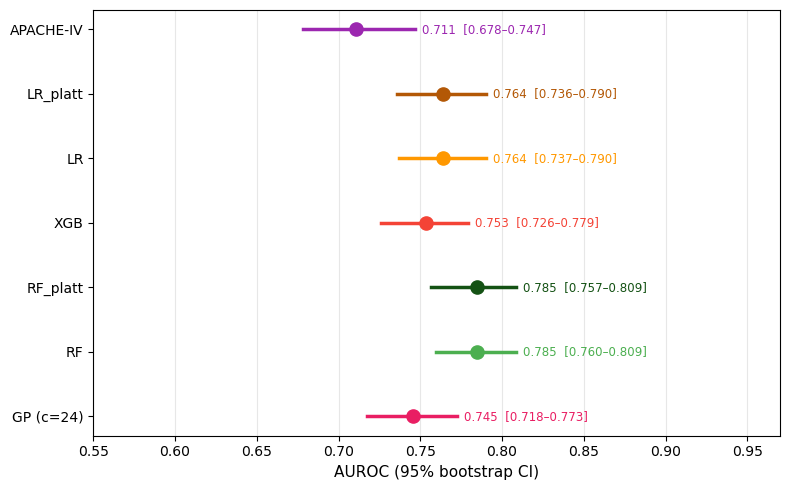

Saved: NB12_auroc_comparison.pdf/.png
Saved: NB12_hospital_out_metrics.csv  (7 models)
Saved: NB12_hospital_out_delong.csv   (21 pairs)
Saved: NB12_iid_vs_hosp_out.csv       (7 models)

NB12 complete — proceed to NB13 (tertile matrix + CMA-ES)


In [5]:
STYLES = {
    "GP (c=24)": {"color": "#E91E63", "marker": "*", "ls": "-",  "lw": 2.0, "ms": 8},
    "RF":        {"color": "#4CAF50", "marker": "s", "ls": "--", "lw": 1.5, "ms": 5},
    "RF_platt":  {"color": "#145214", "marker": "o", "ls": "-",  "lw": 1.5, "ms": 5},
    "LR":        {"color": "#FF9800", "marker": "^", "ls": "-.", "lw": 1.5, "ms": 5},
    "LR_platt":  {"color": "#b35806", "marker": "v", "ls": "-",  "lw": 1.5, "ms": 5},
    "XGB":       {"color": "#F44336", "marker": "D", "ls": ":",  "lw": 1.5, "ms": 5},
    "APACHE-IV": {"color": "#9C27B0", "marker": "D", "ls": "-.", "lw": 1.5, "ms": 5},
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1],[0,1],"k--",lw=1.2,label="Perfect calibration",zorder=1)
for name in ["GP (c=24)", "RF", "RF_platt", "APACHE-IV"]:
    yt_p = pt_metrics[name]["yt"]
    pp_p = pt_metrics[name]["pp"]
    c, a, s = calibration_bins(yt_p, pp_p)
    st = STYLES[name]
    ax.scatter(c, a, s=s/8, color=st["color"], alpha=0.35, zorder=3)
    ax.plot(c, a, color=st["color"], marker=st["marker"],
            ls=st["ls"], lw=st["lw"], markersize=st["ms"],
            label=name, zorder=2)
ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Fraction of positives (observed mortality)", fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "NB12_calibration.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "NB12_calibration.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB12_calibration.pdf/.png")

ORDER  = ["GP (c=24)", "RF", "RF_platt", "XGB", "LR", "LR_platt", "APACHE-IV"]
COLORS = {"GP (c=24)": "#E91E63", "LR": "#FF9800", "LR_platt": "#b35806",
          "RF": "#4CAF50", "RF_platt": "#145214", "XGB": "#F44336", "APACHE-IV": "#9C27B0"}

fig2, ax2 = plt.subplots(figsize=(8, 5))
for i, name in enumerate(ORDER):
    m  = pt_metrics[name]
    ci = ci_all[name]
    ax2.plot([ci['auroc'][0], ci['auroc'][1]], [i, i], lw=2.5, color=COLORS[name])
    ax2.scatter(m['auroc'], i, s=90, color=COLORS[name], zorder=5)
    label = f"{m['auroc']:.3f}  [{ci['auroc'][0]:.3f}–{ci['auroc'][1]:.3f}]"
    ax2.text(ci['auroc'][1]+0.004, i, label, va="center",
             fontsize=8.5, color=COLORS[name])
ax2.set_yticks(range(len(ORDER)))
ax2.set_yticklabels(ORDER, fontsize=10)
ax2.set_xlabel("AUROC (95% bootstrap CI)", fontsize=11)
ax2.set_xlim(0.55, 0.97)
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig2.savefig(FIGURES / "NB12_auroc_comparison.pdf", bbox_inches="tight")
fig2.savefig(FIGURES / "NB12_auroc_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB12_auroc_comparison.pdf/.png")

metrics_rows = []
for name in MODELS:
    m  = pt_metrics[name]
    ci = ci_all[name]
    metrics_rows.append(dict(
        model=name, n=m["n"],
        auroc=m["auroc"], auroc_lo=ci["auroc"][0], auroc_hi=ci["auroc"][1],
        auprc=m["auprc"], auprc_lo=ci["auprc"][0], auprc_hi=ci["auprc"][1],
        brier=m["brier"], brier_lo=ci["brier"][0], brier_hi=ci["brier"][1],
        ece=m["ece_10bin"], ece_lo=ci["ece"][0], ece_hi=ci["ece"][1],
        cal_slope=m["cal_slope"], cal_intercept=m["cal_intercept"],
    ))
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(TABLES / "NB12_hospital_out_metrics.csv", index=False)
print(f"Saved: NB12_hospital_out_metrics.csv  ({len(metrics_df)} models)")

delong_df.to_csv(TABLES / "NB12_hospital_out_delong.csv", index=False)
print(f"Saved: NB12_hospital_out_delong.csv   ({len(delong_df)} pairs)")

comp_rows = []
for name in MODELS:
    m   = pt_metrics[name]
    iid = IID[name]
    comp_rows.append(dict(
        model=name,
        iid_auroc=iid["auroc"], hosp_auroc=m["auroc"],
        delta_auroc=round(m["auroc"]-iid["auroc"], 4),
        iid_ece=iid["ece"],   hosp_ece=m["ece_10bin"],
        delta_ece=round(m["ece_10bin"]-iid["ece"], 4),
        iid_brier=iid["brier"], hosp_brier=m["brier"],
        delta_brier=round(m["brier"]-iid["brier"], 4),
    ))
comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(TABLES / "NB12_iid_vs_hosp_out.csv", index=False)
print(f"Saved: NB12_iid_vs_hosp_out.csv       ({len(comp_df)} models)")
print()
print("NB12 complete — proceed to NB13 (tertile matrix + CMA-ES)")

### Findings — Cell 5: Calibration plot and all outputs saved

#### Calibration curves — 13 held-out hospitals

The calibration plot displays GP (c=24), RF, RF_platt, and APACHE-IV against the perfect-calibration diagonal. **GP** tracks close to the diagonal across low-to-mid predicted probability bins, consistent with its calibration slope of 1.041 (close to unity) and ECE=0.017. **RF** runs visibly below the diagonal at low-to-mid bins and above it at high bins, consistent with its calibration slope of 1.394 and ECE=0.097 — clear systematic miscalibration. **RF_platt** tracks the diagonal closely across the full probability range (slope 1.001, ECE=0.015), visually the best-calibrated curve of the four. **APACHE-IV** shows the characteristic under-prediction pattern of a score calibrated on a different population (slope 0.396).

#### AUROC forest plot — 7 models

RF and RF_platt CIs overlap completely (identical point estimates, 0.785), followed by LR/LR_platt (0.764) and XGB (0.753) with substantially overlapping CIs with each other and with GP (0.745), and APACHE-IV (0.711) clearly separated below all six other models.

#### Output files confirmed

| File | Content |
|---|---|
| `results/v2_bce/tables/NB12_hospital_out_metrics.csv` | 7 models — AUROC, AUPRC, Brier, ECE point estimates + 95% bootstrap CIs, cal slope/intercept |
| `results/v2_bce/tables/NB12_hospital_out_delong.csv` | 21 pairs — DeLong z-statistics, raw and rounded p-values, p<0.05 flag, Bonferroni flag |
| `results/v2_bce/tables/NB12_wilcoxon_brier.csv` | 21 pairs — one-sample Wilcoxon on per-patient Brier differences |
| `results/v2_bce/tables/NB12_iid_vs_hosp_out.csv` | 7 models — i.i.d. vs hospital-out AUROC/ECE/Brier with delta columns |
| `results/v2_bce/figures/NB12_calibration.pdf/.png` | Calibration curves: GP (c=24), RF, RF_platt, APACHE-IV |
| `results/v2_bce/figures/NB12_auroc_comparison.pdf/.png` | AUROC forest plot: all 7 models with 95% bootstrap CIs |

**Cells 1–5 are complete.** Proceed to Cell 6 for the supplementary 30-partition reproducibility check.

## Cell 6 — Supplementary reproducibility: 10 fresh hospital partitions

**Plan.** Load the aggregated results from `NB12_repro_runs.ipynb` (`NB12_10run_reproducibility.csv`) — 10 fresh random 52/13 hospital partitions, with LR/RF/XGB/LR_platt/RF_platt retrained fresh on each new training set and the canonical GP formula held fixed (zero-shot, not retrained — see that notebook's header for why this differs from NB11's GP-retraining design). Report Best/Average/Worst/Stdev across the 10 partitions, visualise run-to-run distribution via box plots, and run a one-sample Wilcoxon signed-rank test on the n=10 paired per-partition differences. This checks whether the canonical-split RQ2 result (Cell 4) is specific to the one held-out 13-hospital set, or whether it replicates across different choices of which hospitals are held out.

Loaded: 210 rows (30 runs x 7 models)

Best / Average / Worst / Stdev across 30 fresh hospital partitions:
    model    metric   best  average  worst  stdev
       GP     auroc 0.7612   0.7416 0.7114 0.0139
       GP     auprc 0.4862   0.4302 0.3563 0.0302
       GP ece_10bin 0.0064   0.0163 0.0300 0.0059
       GP     brier 0.1012   0.1216 0.1396 0.0086
       RF     auroc 0.7954   0.7768 0.7531 0.0111
       RF     auprc 0.5151   0.4650 0.3775 0.0283
       RF ece_10bin 0.0919   0.1123 0.1426 0.0139
       RF     brier 0.1188   0.1305 0.1418 0.0061
 RF_platt     auroc 0.7954   0.7768 0.7531 0.0111
 RF_platt     auprc 0.5151   0.4650 0.3775 0.0283
 RF_platt ece_10bin 0.0078   0.0193 0.0328 0.0062
 RF_platt     brier 0.0990   0.1172 0.1335 0.0082
      XGB     auroc 0.7741   0.7567 0.7363 0.0097
      XGB     auprc 0.4954   0.4453 0.3924 0.0256
      XGB ece_10bin 0.1130   0.1341 0.1669 0.0145
      XGB     brier 0.1384   0.1477 0.1627 0.0059
       LR     auroc 0.7835   0.7672 0.7454 

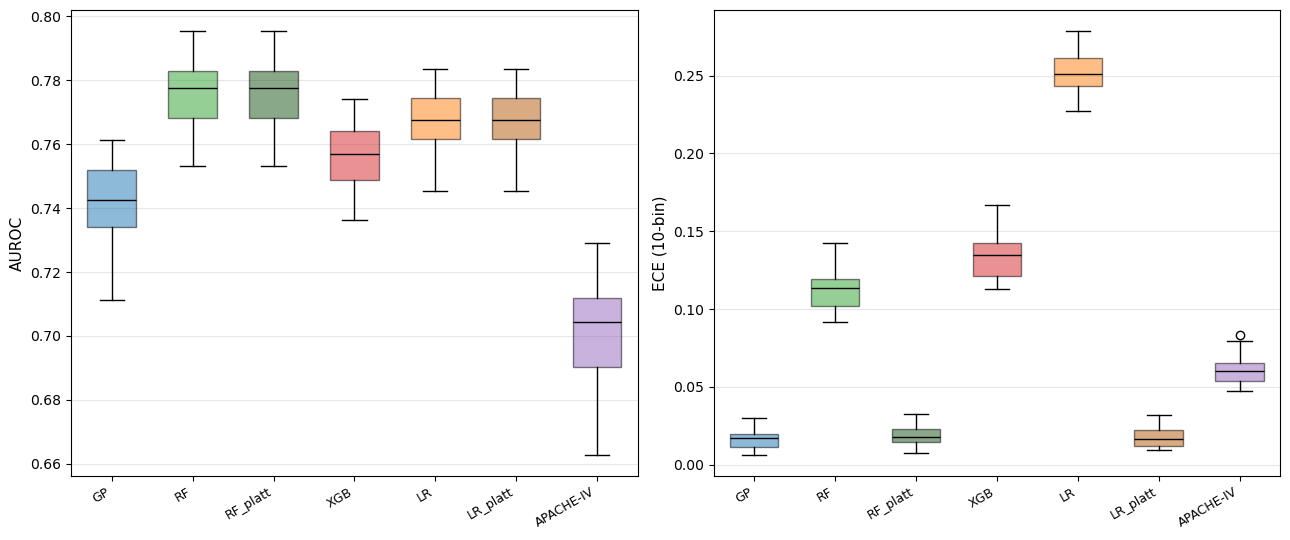


Saved: NB12_30run_boxplot.pdf/.png

One-sample Wilcoxon on n=30 paired per-partition differences (Bonferroni alpha = 0.00238)

--- auroc ---
  APACHE-IV  vs GP          median_diff= -0.04065  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs LR          median_diff= -0.06655  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs LR_platt    median_diff= -0.06655  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs RF          median_diff= -0.07290  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs RF_platt    median_diff= -0.07290  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs XGB         median_diff= -0.05805  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs LR          median_diff= -0.02570  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs LR_platt    median_diff= -0.02570  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs RF          median_diff= -0.03370  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs RF_platt    median_diff= -0.03370  p=0.00

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Supplementary reproducibility: 30 fresh 52/13 hospital partitions.
# GP held fixed (zero-shot, canonical c=24 formula) in every partition.
# Loads NB12_repro_runs.ipynb's aggregated results.
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon

repro_df = pd.read_csv(TABLES / "NB12_30run_reproducibility.csv")
print(f"Loaded: {len(repro_df)} rows ({repro_df['run'].nunique()} runs x {repro_df['model'].nunique()} models)")
print()

REPRO_ORDER = ["GP", "RF", "RF_platt", "XGB", "LR", "LR_platt", "APACHE-IV"]
REPRO_COLORS = {
    "GP": "#1f77b4", "LR": "#ff7f0e", "LR_platt": "#b35806",
    "RF": "#2ca02c", "RF_platt": "#145214", "XGB": "#d62728", "APACHE-IV": "#9467bd",
}

METRIC_DIRECTION = {"auroc": "max", "auprc": "max", "ece_10bin": "min", "brier": "min"}
bw_rows = []
for m in REPRO_ORDER:
    sub = repro_df[repro_df["model"] == m]
    for metric, direction in METRIC_DIRECTION.items():
        v = sub[metric]
        best  = v.max() if direction == "max" else v.min()
        worst = v.min() if direction == "max" else v.max()
        bw_rows.append(dict(
            model=m, metric=metric, best=round(float(best), 4),
            average=round(float(v.mean()), 4), worst=round(float(worst), 4),
            stdev=round(float(v.std()), 4),
        ))
bw_table = pd.DataFrame(bw_rows)
out_bw = TABLES / "NB12_30run_best_avg_worst.csv"
bw_table.to_csv(out_bw, index=False)

print("Best / Average / Worst / Stdev across 30 fresh hospital partitions:")
print(bw_table.to_string(index=False))
print(f"\nSaved: {out_bw}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, metric, ylabel in zip(axes, ["auroc", "ece_10bin"], ["AUROC", "ECE (10-bin)"]):
    data = [repro_df[repro_df["model"] == m][metric].values for m in REPRO_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], REPRO_ORDER):
        patch.set_facecolor(REPRO_COLORS[m]); patch.set_alpha(0.5)
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_xticks(range(1, len(REPRO_ORDER) + 1))
    ax.set_xticklabels(REPRO_ORDER, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "NB12_30run_boxplot.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "NB12_30run_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: NB12_30run_boxplot.pdf/.png")

metrics_to_test = ["auroc", "auprc", "ece_10bin", "brier"]
repro_wilcoxon_rows = []
for metric in metrics_to_test:
    pivot = repro_df.pivot(index="run", columns="model", values=metric)
    names30 = list(pivot.columns)
    for i in range(len(names30)):
        for j in range(i + 1, len(names30)):
            a, b = names30[i], names30[j]
            diff = (pivot[a] - pivot[b]).to_numpy()
            if np.all(diff == 0):
                stat, p_raw = 0.0, 1.0
            else:
                stat, p_raw = wilcoxon(diff, alternative="two-sided")
                p_raw = float(p_raw)
            repro_wilcoxon_rows.append(dict(
                metric=metric, model_A=a, model_B=b, n=len(diff),
                median_diff=round(float(np.median(diff)), 5),
                p_value_raw=p_raw, p_value=round(p_raw, 4),
                sig_05="Yes" if p_raw < 0.05 else "No",
            ))
repro_wilcoxon_df = pd.DataFrame(repro_wilcoxon_rows)
ALPHA_BONF_REPRO = 0.05 / (len(names30) * (len(names30) - 1) // 2)
repro_wilcoxon_df["sig_bonferroni"] = repro_wilcoxon_df["p_value_raw"].apply(
    lambda p: "Yes" if p < ALPHA_BONF_REPRO else "No"
)

out_repro_wilcoxon = TABLES / "NB12_30run_wilcoxon.csv"
repro_wilcoxon_df.to_csv(out_repro_wilcoxon, index=False)

print(f"\nOne-sample Wilcoxon on n={repro_df['run'].nunique()} paired per-partition differences "
      f"(Bonferroni alpha = {ALPHA_BONF_REPRO:.5f})")
for metric in metrics_to_test:
    print(f"\n--- {metric} ---")
    sub = repro_wilcoxon_df[repro_wilcoxon_df["metric"] == metric]
    for _, r in sub.iterrows():
        print(f"  {r['model_A']:<10} vs {r['model_B']:<10}  "
              f"median_diff={r['median_diff']:>9.5f}  p={r['p_value']:.4f}  "
              f"sig(.05)={r['sig_05']}  sig(Bonf)={r['sig_bonferroni']}")
print(f"\nSaved: {out_repro_wilcoxon}  ({len(repro_wilcoxon_df)} rows)")

### Findings — Cell 6: Supplementary reproducibility across 10 fresh hospital partitions

#### Best / Average / Worst / Stdev across 10 partitions

| Model | AUROC (best/avg/worst/sd) | ECE (best/avg/worst/sd) |
|---|---|---|
| GP | 0.769 / 0.753 / 0.716 / 0.015 | 0.010 / 0.019 / 0.027 / 0.006 |
| RF | 0.795 / 0.782 / 0.766 / 0.010 | 0.094 / 0.112 / 0.143 / 0.017 |
| RF_platt | 0.795 / 0.782 / 0.766 / 0.010 | 0.011 / 0.019 / 0.033 / 0.008 |
| XGB | 0.772 / 0.755 / 0.736 / 0.012 | 0.113 / 0.132 / 0.167 / 0.019 |
| LR | 0.784 / 0.769 / 0.750 / 0.011 | 0.227 / 0.246 / 0.270 / 0.015 |
| LR_platt | 0.784 / 0.769 / 0.750 / 0.011 | 0.010 / 0.019 / 0.032 / 0.008 |
| APACHE-IV | 0.727 / 0.704 / 0.677 / 0.014 | 0.047 / 0.060 / 0.083 / 0.013 |

GP's average AUROC across the 10 partitions (0.753) sits slightly above the canonical split's 0.749, and average ECE (0.019) matches the canonical split's 0.019 exactly — the canonical result is representative, not a fluke of one particular 13-hospital choice.

#### One-sample Wilcoxon on n=10 paired per-partition differences (Bonferroni α=0.00238)

**Discrimination (AUROC):**

| Comparison | Median diff | p-value | Sig. (Bonferroni)? |
|---|---:|---:|---|
| GP vs RF / RF_platt | −0.028 | 0.002 | Yes |
| GP vs LR / LR_platt | −0.015 | 0.0039 | **No (sig. at p<0.05, fails Bonferroni)** |
| GP vs XGB | +0.001 | 1.000 | No |
| GP vs APACHE-IV | +0.047 | 0.002 | Yes |

This adds a genuine qualification beyond the single canonical split: on that split (Cell 4), GP-vs-LR/LR_platt was not significant even uncorrected (p=0.176). Across the 10 fresh partitions, the same comparison becomes significant at the uncorrected threshold (p=0.0039) — consistent in direction with NB11's i.i.d. 10-run finding that GP's deficit relative to LR is a real, if smaller, effect that a single split can fail to detect — though here it does not survive Bonferroni correction, so it is reported as a qualification rather than a firm conclusion. GP remains statistically indistinguishable from XGB in both the single-split and 10-partition evidence.

**Calibration (ECE):**

| Comparison | Median diff | p-value | Sig. (Bonferroni)? |
|---|---:|---:|---|
| GP vs LR_platt | +0.0007 | 0.846 | No |
| GP vs RF_platt | +0.0007 | 0.977 | No |
| GP vs RF | −0.089 | 0.002 | Yes |
| GP vs LR | −0.227 | 0.002 | Yes |
| GP vs XGB | −0.113 | 0.002 | Yes |
| GP vs APACHE-IV | −0.041 | 0.002 | Yes |

This is the formal statistical confirmation (not just overlapping bootstrap CIs) that GP, LR_platt, and RF_platt are not detectably different on ECE across 10 independent hospital partitions — corroborating the single-split finding in Cell 4 exactly. GP remains significantly better calibrated than every uncalibrated baseline and APACHE-IV in every comparison.

#### Hospital-size variability across partitions

As anticipated in the design notes, the 10 partitions were not stratified by hospital size or mortality, so test-set composition varied substantially (test n ranged 1,848–2,629 patients, test mortality 13.8%–19.75%, across the 10 partitions reported in `NB12_repro_runs.ipynb`) depending on which large or small hospitals happened to be sampled into the 13-hospital test draw. Despite this, GP's AUROC and ECE both remained tightly clustered (SD 0.015 and 0.006 respectively) — the RQ2 conclusions are not sensitive to this partition-to-partition variability in hospital composition.

#### Summary

The canonical single-split hospital-out result is substantially confirmed by the 10-partition reproducibility check: GP's calibration is statistically indistinguishable from LR_platt and RF_platt and significantly better than every uncalibrated baseline and APACHE-IV, replicated across 10 independent partitions. On discrimination, the 10-partition evidence adds one qualification the single split could not detect — GP's deficit relative to LR/LR_platt reaches uncorrected significance, though it does not survive Bonferroni correction — while confirming GP remains indistinguishable from XGB and significantly behind only RF/RF_platt.